# CNN - VNINDEX

## Descriptions
1. Features: ["close"] + ["close_ema_5", "close_ema_10", "close_ema_15", "close_ema5_ema10_diff", "close_ema5_ema15_diff",  "close_ema10_ema15_diff", "close_ema5_slope", "close_ema10_slope", "close_ema15_slope"]
1. Target: "close"
1. Timeshift: 15
1. Forecast horizon: 10
1. Remove dayoffs

## Deploy TensorBoard

In [58]:
# tensorboard --logdir=src/model/lightning_logs/

## Import libraries

In [59]:
import os
import sys
from datetime import datetime, timedelta
import pandas as pd
import lightning as L
import torch.nn as nn
import torch
from torch.optim import Adam
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tsfresh.utilities.dataframe_functions import (
    roll_time_series,
)
from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import ComprehensiveFCParameters
import matplotlib.pylab as plt
from sklearn.preprocessing import MinMaxScaler
from lightning.pytorch.callbacks import EarlyStopping
from dataclasses import asdict
import ipynbname

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from utils.constants import FEATURE_SELECTION_LOG_FILE_BASE
from dtos.config_dtos.config_dto import ConfigDto
from tabular_database_driver.postgre_sql_driver import PostgreSQLDriver
from dtos.tabular_database_driver_dtos.postgre_sql_connection_dto import (
    PostgreSQLConnectionDto,
)
from utils.enums import (
    LossFunctionType,
    ModelAchitectureType,
    OptimizerType,
    ScalerType,
)
from ta.ta_functions import *

## Helper functions

In [60]:
def get_weekends(from_date: str, to_date: str):
    start = datetime.strptime(from_date, "%Y-%m-%d")
    end = datetime.strptime(to_date, "%Y-%m-%d")

    weekends = []
    current = start

    while current <= end:
        if current.weekday() in (5, 6):  # 5 = Saturday, 6 = Sunday
            weekends.append(current.strftime("%Y-%m-%d"))
        current += timedelta(days=1)

    return weekends

## Parameters

In [61]:
NOTEBOOK_NAME = ipynbname.name()
RANDOM_SEED = 18
MAX_TIMESHIFT = 15  # MIN 15
MIN_TIMESHIFT = 5
FORECAST_HORIZON = 10
COLUMN_ID = "stock"
TARGET_COLUMN = "close"
DATE_COLUMN = "date"
FEATURE_COLUMNS = ["close"] + [
    "close_ema_5",
    "close_ema_10",
    "close_ema_15",
    "close_ema5_ema10_diff",
    "close_ema5_ema15_diff",
    "close_ema10_ema15_diff",
    "close_ema5_slope",
    "close_ema10_slope",
    "close_ema15_slope",
]

# Inclusive
TRAIN_RANGE = ("2000-01-01", "2021-12-31")
VALIDATION_RANGE = ("2022-01-01", "2023-12-31")
TEST_RANGE = ("2024-01-01", "2026-02-26")

OUTPUT_SIZE = 1

In [62]:
WEEKENDS = get_weekends(TRAIN_RANGE[0], TEST_RANGE[1])
HOLIDAYS = []

DAYOFFS = []
DAYOFFS.extend(WEEKENDS)
DAYOFFS.extend(HOLIDAYS)

DAYOFFS[:10], DAYOFFS[-10:]

(['2000-01-01',
  '2000-01-02',
  '2000-01-08',
  '2000-01-09',
  '2000-01-15',
  '2000-01-16',
  '2000-01-22',
  '2000-01-23',
  '2000-01-29',
  '2000-01-30'],
 ['2026-01-24',
  '2026-01-25',
  '2026-01-31',
  '2026-02-01',
  '2026-02-07',
  '2026-02-08',
  '2026-02-14',
  '2026-02-15',
  '2026-02-21',
  '2026-02-22'])

## Hyper Parameters

In [ ]:
MAX_EPOCHS = 3000
LEARNING_RATE = 1.0e-06
PATIENCE = 100
BATCH_SIZE = 64

In [64]:
MODEL_PARAMS = {"remove_dayoffs": True}
MODEL_PARAMS

{'remove_dayoffs': True}

## Start

### Get data

In [65]:
my_logger = Logger(file_name=f"{FEATURE_SELECTION_LOG_FILE_BASE}/vn_index/test")

In [66]:
my_connection_model = PostgreSQLConnectionDto(
    logger=my_logger,
    host=os.getenv("POSTGRES_HOST"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    port=os.getenv("POSTGRES_PORT"),
    database=os.getenv("GOLD_POSTGRES_DATABASE"),
)

In [67]:
my_postgresql_driver = PostgreSQLDriver(logger=my_logger)
my_postgresql_driver.connect(my_connection_model)

<DatabaseExecutionStatus.SUCCESS: 'success'>

In [68]:
vn_index_df = my_postgresql_driver.select(
    schema_name="stock_market", table_name="vn_index"
)

In [69]:
dtype_map = {
    "date": str,
    "open": float,
    "high": float,
    "low": float,
    "close": float,
    "matching_volume": float,
}

vn_index_df = (
    vn_index_df.astype(dtype_map)
    .dropna(subset=["close"])
    .sort_values(by=["date"])
    .reset_index(drop=True)
)

In [70]:
vn_index_df

,date,open,high,low,close,adjust,change,percent_change,matching_volume,matching_value,negotiate_volume,negotiate_value,number_of_buy_orders,buy_volume,average_volume_per_buy_order,number_of_sell_orders,sell_volume,average_volume_per_sell_order,net_volume
0,2008-03-07,640.140,640.140,640.140,640.140,640.14,28.97,4.74,8.169220e+06,515253831000.0,350040.0,29103040000.0,26816.0,5.268141e+07,1965.0,3448.0,9.057040e+06,2627.0,4.362437e+07
1,2008-03-08,646.190,646.190,646.190,646.190,646.1899999999999,25.363333333333333,4.1066666666666665,1.314382e+07,829832099333.3333,769057.0,45944657000.0,27442.0,5.068024e+07,1852.3333333333333,7486.0,1.712815e+07,2464.0,3.355209e+07
2,2008-03-09,652.240,652.240,652.240,652.240,652.24,21.756666666666664,3.4733333333333336,1.811842e+07,1144410367666.6665,1188073.0,62786274000.0,28068.0,4.867907e+07,1739.6666666666667,11523.0,2.519927e+07,2301.0,2.347980e+07
3,2008-03-10,658.290,658.290,658.290,658.290,658.29,18.15,2.84,2.309302e+07,1458988636000.0,1607090.0,79627891000.0,28694.0,4.667790e+07,1627.0,15561.0,3.327038e+07,2138.0,1.340752e+07
4,2008-03-11,638.710,638.710,638.710,638.710,638.71,-19.58,-2.97,1.384280e+07,837466500000.0,226000.0,12099600000.0,14464.0,1.933131e+07,1337.0,17910.0,2.811427e+07,1570.0,-8.782960e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6561,2026-02-22,1832.317,1859.236,1829.801,1856.535,1856.535,33.44499999999999,1.837,7.158068e+08,22272405365000.0,23581058.0,792440247700.0,476711.0,1.233848e+09,2591.3,393692.0,1.198445e+09,3047.9,3.540296e+07
6562,2026-02-23,1833.900,1863.130,1833.900,1860.140,1860.14,36.05,1.98,7.313611e+08,22646206050000.0,23192200.0,777430868000.0,486603.0,1.253004e+09,2575.0,401281.0,1.213944e+09,3025.0,3.906029e+07
6563,2026-02-24,1862.180,1867.690,1849.600,1867.620,1867.62,7.48,0.4,9.667547e+08,31205940310000.0,22413147.0,779573446300.0,598087.0,1.575227e+09,2634.0,507471.0,1.648273e+09,3248.0,-7.304628e+07
6564,2026-02-25,1869.490,1876.010,1855.890,1860.910,1860.91,-6.71,-0.36,1.083635e+09,35678521520000.0,62225450.0,1856894317550.0,694266.0,1.862364e+09,2682.0,597096.0,1.892734e+09,3170.0,-3.036983e+07


### Data transformation

#### Remove DAYOFFS

In [71]:
vn_index_df_t1 = vn_index_df[~vn_index_df["date"].isin(DAYOFFS)]
vn_index_df_t1.shape

(4690, 19)

#### Add EMA(5,10,15)

In [72]:
vn_index_df_t2 = add_ema(vn_index_df_t1, n=[5, 10, 15])
vn_index_df_t2.shape

(4690, 22)

In [73]:
vn_index_df_t2["close_ema5_ema10_diff"] = (
    vn_index_df_t2["close_ema_5"] - vn_index_df_t2["close_ema_10"]
)
vn_index_df_t2["close_ema5_ema15_diff"] = (
    vn_index_df_t2["close_ema_5"] - vn_index_df_t2["close_ema_15"]
)
vn_index_df_t2["close_ema10_ema15_diff"] = (
    vn_index_df_t2["close_ema_10"] - vn_index_df_t2["close_ema_15"]
)
vn_index_df_t2["close_ema5_slope"] = vn_index_df_t2["close_ema_5"].diff()
vn_index_df_t2["close_ema10_slope"] = vn_index_df_t2["close_ema_10"].diff()
vn_index_df_t2["close_ema15_slope"] = vn_index_df_t2["close_ema_15"].diff()
vn_index_df_t2.shape

(4690, 28)

In [74]:
vn_index_df_final = vn_index_df_t2[[DATE_COLUMN] + FEATURE_COLUMNS]
vn_index_df_final

,date,close,close_ema_5,close_ema_10,close_ema_15,close_ema5_ema10_diff,close_ema5_ema15_diff,close_ema10_ema15_diff,close_ema5_slope,close_ema10_slope,close_ema15_slope
0,2008-03-07,640.140,640.140000,640.140000,640.140000,0.000000,0.000000,0.000000,NaN,NaN,NaN
3,2008-03-10,658.290,646.190000,643.440000,642.408750,2.750000,3.781250,1.031250,6.050000,3.300000,2.268750
4,2008-03-11,638.710,643.696667,642.580000,641.946406,1.116667,1.750260,0.633594,-2.493333,-0.860000,-0.462344
5,2008-03-12,643.900,643.764444,642.820000,642.190605,0.944444,1.573839,0.629395,0.067778,0.240000,0.244199
6,2008-03-13,647.600,645.042963,643.689091,642.866780,1.353872,2.176183,0.822311,1.278519,0.869091,0.676174
...,...,...,...,...,...,...,...,...,...,...,...
6559,2026-02-20,1849.325,1839.113461,1827.500237,1823.421182,11.613224,15.692280,4.079055,5.105769,4.849947,3.700545
6562,2026-02-23,1860.140,1846.122307,1833.434739,1828.011034,12.687568,18.111274,5.423705,7.008846,5.934502,4.589852
6563,2026-02-24,1867.620,1853.288205,1839.650241,1832.962155,13.637964,20.326050,6.688086,7.165898,6.215502,4.951121
6564,2026-02-25,1860.910,1855.828803,1843.515652,1836.455635,12.313152,19.373168,7.060016,2.540598,3.865411,3.493481


In [75]:
vn_index_df_final.loc[:, "stock"] = "vn_index"
vn_index_df_final

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33608\1961083148.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vn_index_df_final.loc[:, "stock"] = "vn_index"


,date,close,close_ema_5,close_ema_10,close_ema_15,close_ema5_ema10_diff,close_ema5_ema15_diff,close_ema10_ema15_diff,close_ema5_slope,close_ema10_slope,close_ema15_slope,stock
0,2008-03-07,640.140,640.140000,640.140000,640.140000,0.000000,0.000000,0.000000,NaN,NaN,NaN,vn_index
3,2008-03-10,658.290,646.190000,643.440000,642.408750,2.750000,3.781250,1.031250,6.050000,3.300000,2.268750,vn_index
4,2008-03-11,638.710,643.696667,642.580000,641.946406,1.116667,1.750260,0.633594,-2.493333,-0.860000,-0.462344,vn_index
5,2008-03-12,643.900,643.764444,642.820000,642.190605,0.944444,1.573839,0.629395,0.067778,0.240000,0.244199,vn_index
6,2008-03-13,647.600,645.042963,643.689091,642.866780,1.353872,2.176183,0.822311,1.278519,0.869091,0.676174,vn_index
...,...,...,...,...,...,...,...,...,...,...,...,...
6559,2026-02-20,1849.325,1839.113461,1827.500237,1823.421182,11.613224,15.692280,4.079055,5.105769,4.849947,3.700545,vn_index
6562,2026-02-23,1860.140,1846.122307,1833.434739,1828.011034,12.687568,18.111274,5.423705,7.008846,5.934502,4.589852,vn_index
6563,2026-02-24,1867.620,1853.288205,1839.650241,1832.962155,13.637964,20.326050,6.688086,7.165898,6.215502,4.951121,vn_index
6564,2026-02-25,1860.910,1855.828803,1843.515652,1836.455635,12.313152,19.373168,7.060016,2.540598,3.865411,3.493481,vn_index


In [76]:
vn_index_df_final.shape

(4690, 12)

In [77]:
input_df = vn_index_df_final
input_df

,date,close,close_ema_5,close_ema_10,close_ema_15,close_ema5_ema10_diff,close_ema5_ema15_diff,close_ema10_ema15_diff,close_ema5_slope,close_ema10_slope,close_ema15_slope,stock
0,2008-03-07,640.140,640.140000,640.140000,640.140000,0.000000,0.000000,0.000000,NaN,NaN,NaN,vn_index
3,2008-03-10,658.290,646.190000,643.440000,642.408750,2.750000,3.781250,1.031250,6.050000,3.300000,2.268750,vn_index
4,2008-03-11,638.710,643.696667,642.580000,641.946406,1.116667,1.750260,0.633594,-2.493333,-0.860000,-0.462344,vn_index
5,2008-03-12,643.900,643.764444,642.820000,642.190605,0.944444,1.573839,0.629395,0.067778,0.240000,0.244199,vn_index
6,2008-03-13,647.600,645.042963,643.689091,642.866780,1.353872,2.176183,0.822311,1.278519,0.869091,0.676174,vn_index
...,...,...,...,...,...,...,...,...,...,...,...,...
6559,2026-02-20,1849.325,1839.113461,1827.500237,1823.421182,11.613224,15.692280,4.079055,5.105769,4.849947,3.700545,vn_index
6562,2026-02-23,1860.140,1846.122307,1833.434739,1828.011034,12.687568,18.111274,5.423705,7.008846,5.934502,4.589852,vn_index
6563,2026-02-24,1867.620,1853.288205,1839.650241,1832.962155,13.637964,20.326050,6.688086,7.165898,6.215502,4.951121,vn_index
6564,2026-02-25,1860.910,1855.828803,1843.515652,1836.455635,12.313152,19.373168,7.060016,2.540598,3.865411,3.493481,vn_index


### Roll time series

In [82]:
input_df_rolled = roll_time_series(
    input_df,
    column_id=COLUMN_ID,
    column_sort=DATE_COLUMN,
    max_timeshift=MAX_TIMESHIFT,
    min_timeshift=MIN_TIMESHIFT,
)
input_df_rolled

Rolling: 100%|██████████| 50/50 [00:06<00:00,  7.72it/s]


,date,close,stock,id
1034,2008-03-07,640.140,vn_index,"(vn_index, 2008-03-14)"
1035,2008-03-10,658.290,vn_index,"(vn_index, 2008-03-14)"
1036,2008-03-11,638.710,vn_index,"(vn_index, 2008-03-14)"
1037,2008-03-12,643.900,vn_index,"(vn_index, 2008-03-14)"
1038,2008-03-13,647.600,vn_index,"(vn_index, 2008-03-14)"
...,...,...,...,...
51515,2026-02-20,1849.325,vn_index,"(vn_index, 2026-02-26)"
51516,2026-02-23,1860.140,vn_index,"(vn_index, 2026-02-26)"
51517,2026-02-24,1867.620,vn_index,"(vn_index, 2026-02-26)"
51518,2026-02-25,1860.910,vn_index,"(vn_index, 2026-02-26)"


### Extract features

In [83]:
X = extract_features(
    input_df_rolled.drop(COLUMN_ID, axis=1),
    column_id="id",
    column_sort=DATE_COLUMN,
    impute_function=impute,
    default_fc_parameters=ComprehensiveFCParameters(),
)

Feature Extraction: 100%|██████████| 50/50 [00:46<00:00,  1.07it/s]


In [84]:
X

close__variance_larger_than_standard_deviation  \
vn_index 2008-03-14                                             1.0   
         2008-03-17                                             1.0   
         2008-03-18                                             1.0   
         2008-03-19                                             1.0   
         2008-03-20                                             1.0   
...                                                             ...   
         2026-02-20                                             1.0   
         2026-02-23                                             1.0   
         2026-02-24                                             1.0   
         2026-02-25                                             1.0   
         2026-02-26                                             1.0   

                     close__has_duplicate_max  close__has_duplicate_min  \
vn_index 2008-03-14                       0.0                       0.0   
         2008-03-17                       0.0                       0.0   
         2008-03-18                       0.0                       0.0   
         2008-03-19                       0.0                       0.0   
         2008-03-20                       0.0                       0.0   
...                                       ...                       ...   
         2026-02-20                       0.0                       0.0   
         2026-02-23                       0.0                       0.0   
         2026-02-24                       0.0                       0.0   
         2026-02-25                       0.0                       0.0   
         2026-02-26                       0.0                       0.0   

                     close__has_duplicate  close__sum_values  \
vn_index 2008-03-14                   0.0           3872.440   
         2008-03-17                   0.0           4488.150   
         2008-03-18                   0.0           5076.410   
         2008-03-19                   0.0           5649.860   
         2008-03-20                   0.0           6214.680   
...                                   ...                ...   
         2026-02-20                   0.0          19909.945   
         2026-02-23                   0.0          20014.595   
         2026-02-24                   0.0          20127.395   
         2026-02-25                   0.0          20234.275   
         2026-02-26                   0.0          20317.065   

                     close__abs_energy  close__mean_abs_change  \
vn_index 2008-03-14       2.499547e+06               10.084000   
         2008-03-17       2.878646e+06               13.085000   
         2008-03-18       3.224695e+06               15.137143   
         2008-03-19       3.553540e+06               15.096250   
         2008-03-20       3.872562e+06               14.377778   
...                                ...                     ...   
         2026-02-20       3.605172e+07                9.675500   
         2026-02-23       3.643010e+07               10.690000   
         2026-02-24       3.683871e+07               11.359000   
         2026-02-25       3.722508e+07                7.748000   
         2026-02-26       3.752945e+07                7.897000   

                     close__mean_change  \
vn_index 2008-03-14            0.732000   
         2008-03-17           -4.071667   
         2008-03-18           -7.411429   
         2008-03-19           -8.336250   
         2008-03-20           -8.368889   
...                                 ...   
         2026-02-20            9.383500   
         2026-02-23           10.532000   
         2026-02-24           11.359000   
         2026-02-25            6.406000   
         2026-02-26            6.555000   

                     close__mean_second_derivative_central  close__median  \
vn_index 2008-03-14                              -2.743750        643.850   
         2008-03-17               

In [85]:
X = X.set_index(X.index.map(lambda x: x[1]), drop=True)
X.index.name = "last_date"
X

,close__variance_larger_than_standard_deviation,close__has_duplicate_max,close__has_duplicate_min,close__has_duplicate,close__sum_values,close__abs_energy,close__mean_abs_change,close__mean_change,close__mean_second_derivative_central,close__median,...,close__fourier_entropy__bins_5,close__fourier_entropy__bins_10,close__fourier_entropy__bins_100,close__permutation_entropy__dimension_3__tau_1,close__permutation_entropy__dimension_4__tau_1,close__permutation_entropy__dimension_5__tau_1,close__permutation_entropy__dimension_6__tau_1,close__permutation_entropy__dimension_7__tau_1,close__query_similarity_count__query_None__threshold_0.0,close__mean_n_absolute_max__number_of_maxima_7
last_date,,,,,,,,,,,,,,,,,,,,,
2008-03-14,1.0,0.0,0.0,0.0,3872.440,2.499547e+06,10.084000,0.732000,-2.743750,643.850,...,1.039721,1.386294,1.386294,1.039721,1.098612,0.693147,-0.000000,1.609438,0.0,715.148571
2008-03-17,1.0,0.0,0.0,0.0,4488.150,2.878646e+06,13.085000,-4.071667,-4.624000,643.800,...,1.039721,1.386294,1.386294,1.332179,1.386294,1.098612,0.693147,-0.000000,0.0,715.148571
2008-03-18,1.0,0.0,0.0,0.0,5076.410,3.224695e+06,15.137143,-7.411429,-3.800000,641.970,...,0.950271,1.332179,1.332179,1.329661,1.609438,1.386294,1.098612,0.693147,0.0,641.164286
2008-03-19,1.0,0.0,0.0,0.0,5649.860,3.553540e+06,15.096250,-8.336250,-2.354286,640.140,...,0.950271,0.950271,1.609438,1.277034,1.560710,1.609438,1.386294,1.098612,0.0,641.164286
2008-03-20,1.0,0.0,0.0,0.0,6214.680,3.872562e+06,14.377778,-8.368889,-1.673750,639.425,...,0.867563,0.867563,1.329661,1.213008,1.475076,1.560710,1.609438,1.386294,0.0,641.164286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-20,1.0,0.0,0.0,0.0,19909.945,3.605172e+07,9.675500,9.383500,0.237500,1824.090,...,0.867563,0.867563,1.560710,0.683739,0.735622,0.796312,0.867563,0.950271,0.0,1835.536429
2026-02-23,1.0,0.0,0.0,0.0,20014.595,3.643010e+07,10.690000,10.532000,0.644722,1834.905,...,0.867563,0.867563,1.242453,0.348832,0.376770,0.410116,0.450561,0.500402,0.0,1842.115000
2026-02-24,1.0,0.0,0.0,0.0,20127.395,3.683871e+07,11.359000,11.359000,-1.963333,1838.510,...,0.867563,0.867563,0.867563,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.0,1848.333571


### Create forecast target

In [86]:
y = (
    input_df.set_index(DATE_COLUMN)
    .sort_index()[TARGET_COLUMN]
    .shift(-FORECAST_HORIZON)
    .dropna()
)
y = pd.DataFrame(y)
y

,close
date,
2008-03-07,643.800
2008-03-10,615.710
2008-03-11,588.260
2008-03-12,573.450
2008-03-13,564.820
...,...
2026-02-13,1849.325
2026-02-16,1860.140
2026-02-17,1867.620


In [87]:
y = y[y.index.isin(X.index)]
X = X[X.index.isin(y.index)]

In [88]:
X

,close__variance_larger_than_standard_deviation,close__has_duplicate_max,close__has_duplicate_min,close__has_duplicate,close__sum_values,close__abs_energy,close__mean_abs_change,close__mean_change,close__mean_second_derivative_central,close__median,...,close__fourier_entropy__bins_5,close__fourier_entropy__bins_10,close__fourier_entropy__bins_100,close__permutation_entropy__dimension_3__tau_1,close__permutation_entropy__dimension_4__tau_1,close__permutation_entropy__dimension_5__tau_1,close__permutation_entropy__dimension_6__tau_1,close__permutation_entropy__dimension_7__tau_1,close__query_similarity_count__query_None__threshold_0.0,close__mean_n_absolute_max__number_of_maxima_7
last_date,,,,,,,,,,,,,,,,,,,,,
2008-03-14,1.0,0.0,0.0,0.0,3872.440,2.499547e+06,10.084000,0.732000,-2.743750,643.850,...,1.039721,1.386294,1.386294,1.039721,1.098612,0.693147,-0.000000,1.609438,0.0,715.148571
2008-03-17,1.0,0.0,0.0,0.0,4488.150,2.878646e+06,13.085000,-4.071667,-4.624000,643.800,...,1.039721,1.386294,1.386294,1.332179,1.386294,1.098612,0.693147,-0.000000,0.0,715.148571
2008-03-18,1.0,0.0,0.0,0.0,5076.410,3.224695e+06,15.137143,-7.411429,-3.800000,641.970,...,0.950271,1.332179,1.332179,1.329661,1.609438,1.386294,1.098612,0.693147,0.0,641.164286
2008-03-19,1.0,0.0,0.0,0.0,5649.860,3.553540e+06,15.096250,-8.336250,-2.354286,640.140,...,0.950271,0.950271,1.609438,1.277034,1.560710,1.609438,1.386294,1.098612,0.0,641.164286
2008-03-20,1.0,0.0,0.0,0.0,6214.680,3.872562e+06,14.377778,-8.368889,-1.673750,639.425,...,0.867563,0.867563,1.329661,1.213008,1.475076,1.560710,1.609438,1.386294,0.0,641.164286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-13,1.0,0.0,0.0,0.0,19722.300,3.536865e+07,15.887000,-0.495000,1.807778,1796.850,...,1.011404,1.011404,1.560710,1.427061,1.667462,1.747868,1.791759,1.609438,0.0,1810.771429
2026-02-16,1.0,0.0,0.0,0.0,19728.165,3.539014e+07,14.714500,2.840500,0.217500,1796.850,...,1.242453,1.242453,1.791759,1.214890,1.494175,1.747868,1.791759,1.609438,0.0,1811.609286
2026-02-17,1.0,0.0,0.0,0.0,19760.175,3.550681e+07,14.385000,2.511000,1.420833,1796.850,...,0.867563,1.242453,1.560710,0.964963,1.255482,1.549826,1.791759,1.609438,0.0,1816.182143


In [89]:
y

,close
date,
2008-03-14,545.680
2008-03-17,521.070
2008-03-18,496.640
2008-03-19,504.670
2008-03-20,508.750
...,...
2026-02-13,1849.325
2026-02-16,1860.140
2026-02-17,1867.620


### Create train set

In [90]:
TRAIN_RANGE[0], TRAIN_RANGE[1]

('2000-01-01', '2021-12-31')

In [91]:
X_train = X.loc[TRAIN_RANGE[0] : TRAIN_RANGE[1]]
X_train

,close__variance_larger_than_standard_deviation,close__has_duplicate_max,close__has_duplicate_min,close__has_duplicate,close__sum_values,close__abs_energy,close__mean_abs_change,close__mean_change,close__mean_second_derivative_central,close__median,...,close__fourier_entropy__bins_5,close__fourier_entropy__bins_10,close__fourier_entropy__bins_100,close__permutation_entropy__dimension_3__tau_1,close__permutation_entropy__dimension_4__tau_1,close__permutation_entropy__dimension_5__tau_1,close__permutation_entropy__dimension_6__tau_1,close__permutation_entropy__dimension_7__tau_1,close__query_similarity_count__query_None__threshold_0.0,close__mean_n_absolute_max__number_of_maxima_7
last_date,,,,,,,,,,,,,,,,,,,,,
2008-03-14,1.0,0.0,0.0,0.0,3872.44,2.499547e+06,10.084000,0.732000,-2.743750,643.850,...,1.039721,1.386294,1.386294,1.039721,1.098612,0.693147,-0.000000,1.609438,0.0,715.148571
2008-03-17,1.0,0.0,0.0,0.0,4488.15,2.878646e+06,13.085000,-4.071667,-4.624000,643.800,...,1.039721,1.386294,1.386294,1.332179,1.386294,1.098612,0.693147,-0.000000,0.0,715.148571
2008-03-18,1.0,0.0,0.0,0.0,5076.41,3.224695e+06,15.137143,-7.411429,-3.800000,641.970,...,0.950271,1.332179,1.332179,1.329661,1.609438,1.386294,1.098612,0.693147,0.0,641.164286
2008-03-19,1.0,0.0,0.0,0.0,5649.86,3.553540e+06,15.096250,-8.336250,-2.354286,640.140,...,0.950271,0.950271,1.609438,1.277034,1.560710,1.609438,1.386294,1.098612,0.0,641.164286
2008-03-20,1.0,0.0,0.0,0.0,6214.68,3.872562e+06,14.377778,-8.368889,-1.673750,639.425,...,0.867563,0.867563,1.329661,1.213008,1.475076,1.560710,1.609438,1.386294,0.0,641.164286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-27,1.0,0.0,0.0,0.0,16240.74,2.397889e+07,6.257000,1.267000,0.668889,1477.030,...,1.329661,1.329661,1.791759,1.581094,2.079442,1.945910,1.791759,1.609438,0.0,1479.435714
2021-12-28,1.0,0.0,0.0,0.0,16258.92,2.403289e+07,6.789000,1.837000,0.335000,1477.330,...,1.560710,1.791759,1.791759,1.522955,2.079442,1.945910,1.791759,1.609438,0.0,1481.975714
2021-12-29,1.0,0.0,0.0,0.0,16268.72,2.406192e+07,7.594000,1.032000,-0.537778,1477.670,...,1.329661,1.560710,1.560710,1.522955,2.079442,1.945910,1.791759,1.609438,0.0,1483.231429


In [92]:
y_train = y.loc[TRAIN_RANGE[0] : TRAIN_RANGE[1]]
y_train

,close
date,
2008-03-14,545.680
2008-03-17,521.070
2008-03-18,496.640
2008-03-19,504.670
2008-03-20,508.750
...,...
2021-12-27,1518.755
2021-12-28,1525.580
2021-12-29,1522.500


### Select features

In [93]:
X_train_selected = select_features(X_train, y_train[TARGET_COLUMN])
X_train_selected

,close__sum_values,"close__cwt_coefficients__coeff_4__w_20__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_4__w_5__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_4__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_3__w_20__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_3__w_10__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_3__w_5__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_3__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_2__w_20__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_2__w_10__widths_(2, 5, 10, 20)",...,close__autocorrelation__lag_1,close__partial_autocorrelation__lag_1,close__count_below_mean,close__index_mass_quantile__q_0.9,close__permutation_entropy__dimension_4__tau_1,close__permutation_entropy__dimension_3__tau_1,close__index_mass_quantile__q_0.1,close__ratio_beyond_r_sigma__r_2.5,close__energy_ratio_by_chunks__num_segments_10__segment_focus_3,close__lempel_ziv_complexity__bins_5
last_date,,,,,,,,,,,,,,,,,,,,,
2008-03-14,3872.44,741.856931,1188.237388,692.470534,735.340183,1017.887891,1257.052144,770.416758,742.028130,997.584632,...,-0.729336,-0.729336,4.0,1.000000,1.098612,1.039721,0.166667,0.000000,0.165873,0.833333
2008-03-17,4488.15,851.193745,1348.205763,602.069920,851.178259,1153.942989,1351.505932,607.018917,854.306769,1121.232998,...,-0.114802,-0.114802,3.0,1.000000,1.386294,1.332179,0.142857,0.000000,0.144029,0.714286
2008-03-18,5076.41,961.867449,1438.448548,445.956792,958.451216,1272.078780,1380.434518,491.014815,957.393040,1219.240738,...,0.400753,0.400753,2.0,1.000000,1.609438,1.329661,0.125000,0.000000,0.128573,0.750000
2008-03-19,5649.86,1066.439708,1466.648830,332.873203,1058.942192,1367.619082,1355.607362,437.248469,1053.088024,1290.922161,...,0.657105,0.657105,3.0,1.000000,1.560710,1.277034,0.111111,0.000000,0.116674,0.666667
2008-03-20,6214.68,1165.418369,1442.195304,279.916000,1153.197037,1438.221752,1291.709455,419.494368,1135.340887,1342.856771,...,0.779953,0.779953,4.0,0.900000,1.475076,1.213008,0.100000,0.000000,0.107063,0.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-27,16240.74,3011.653547,3169.500401,508.394668,2948.748337,3517.281348,2709.105894,884.997922,2904.710302,3220.767703,...,-0.038617,-0.038617,4.0,0.909091,2.079442,1.581094,0.181818,0.090909,0.091321,0.545455
2021-12-28,16258.92,3014.728777,3166.848804,509.832951,2951.546302,3518.944567,2705.782843,888.608388,2907.302893,3221.613194,...,0.260064,0.260064,7.0,0.909091,2.079442,1.522955,0.181818,0.000000,0.090813,0.636364
2021-12-29,16268.72,3016.828054,3166.378456,504.797612,2953.409257,3520.722966,2704.521015,890.062455,2908.868945,3222.879415,...,0.389046,0.389046,7.0,0.909091,2.079442,1.522955,0.181818,0.000000,0.090877,0.636364


### Create validation set

In [94]:
VALIDATION_RANGE[0], VALIDATION_RANGE[1]

('2022-01-01', '2023-12-31')

In [95]:
X_validation_selected = X.loc[VALIDATION_RANGE[0] : VALIDATION_RANGE[1]][
    X_train_selected.columns
]
X_validation_selected

,close__sum_values,"close__cwt_coefficients__coeff_4__w_20__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_4__w_5__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_4__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_3__w_20__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_3__w_10__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_3__w_5__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_3__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_2__w_20__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_2__w_10__widths_(2, 5, 10, 20)",...,close__autocorrelation__lag_1,close__partial_autocorrelation__lag_1,close__count_below_mean,close__index_mass_quantile__q_0.9,close__permutation_entropy__dimension_4__tau_1,close__permutation_entropy__dimension_3__tau_1,close__index_mass_quantile__q_0.1,close__ratio_beyond_r_sigma__r_2.5,close__energy_ratio_by_chunks__num_segments_10__segment_focus_3,close__lempel_ziv_complexity__bins_5
last_date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,16339.825,3028.928369,3168.928632,485.234220,2964.961958,3530.960798,2700.160285,864.288058,2920.367245,3230.817956,...,0.457819,0.457819,5.0,0.909091,1.732868,1.427061,0.181818,0.0,0.089874,0.727273
2022-01-04,16388.075,3037.794775,3172.610710,495.872992,2973.152505,3538.695126,2700.087362,865.504215,2927.923892,3236.629143,...,0.646433,0.646433,7.0,0.909091,1.494175,1.149060,0.181818,0.0,0.090780,0.636364
2022-01-05,16431.835,3046.335349,3180.483240,503.055792,2981.305107,3547.661284,2704.042135,876.540968,2935.409187,3243.846996,...,0.761272,0.761272,6.0,0.909091,1.494175,1.149060,0.181818,0.0,0.090964,0.727273
2022-01-06,16482.735,3055.499743,3191.503427,497.891249,2990.930943,3558.390706,2711.115103,883.392917,2944.648240,3253.398928,...,0.686370,0.686370,7.0,0.909091,1.667462,1.303092,0.181818,0.0,0.089366,0.636364
2022-01-07,16554.255,3068.609448,3206.404161,485.101781,3003.978556,3574.965610,2725.326623,872.733026,2957.938433,3269.360372,...,0.788417,0.788417,6.0,0.909091,1.906155,1.427061,0.181818,0.0,0.088619,0.545455
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-25,12191.850,2260.662839,2376.693057,371.390932,2213.819844,2641.542161,2038.298641,675.710386,2181.253742,2420.378187,...,0.693463,0.693463,6.0,0.909091,1.494175,1.214890,0.181818,0.0,0.089910,0.727273
2023-12-26,12188.600,2259.701603,2367.028139,360.253776,2212.343745,2637.405105,2025.859633,661.407716,2179.693778,2415.228680,...,0.564548,0.564548,6.0,0.909091,1.213008,0.936888,0.181818,0.0,0.088266,0.727273
2023-12-27,12182.960,2258.452058,2361.587371,356.770906,2210.943914,2633.646553,2015.909239,650.837831,2177.801039,2410.539534,...,0.731683,0.731683,6.0,0.909091,1.386294,1.149060,0.181818,0.0,0.089066,0.636364


In [96]:
y_validation = y.loc[VALIDATION_RANGE[0] : VALIDATION_RANGE[1]]
y_validation

,close
date,
2022-01-03,1503.7100
2022-01-04,1492.3100
2022-01-05,1510.5100
2022-01-06,1496.0500
2022-01-07,1496.0200
...,...
2023-12-25,1131.2725
2023-12-26,1131.7200
2023-12-27,1144.1700


### Create test set

In [97]:
TEST_RANGE[0], TEST_RANGE[1]

('2024-01-01', '2026-02-26')

In [98]:
X_test_selected = X.loc[TEST_RANGE[0] : TEST_RANGE[1]][X_train_selected.columns]
X_test_selected

,close__sum_values,"close__cwt_coefficients__coeff_4__w_20__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_4__w_5__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_4__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_3__w_20__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_3__w_10__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_3__w_5__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_3__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_2__w_20__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_2__w_10__widths_(2, 5, 10, 20)",...,close__autocorrelation__lag_1,close__partial_autocorrelation__lag_1,close__count_below_mean,close__index_mass_quantile__q_0.9,close__permutation_entropy__dimension_4__tau_1,close__permutation_entropy__dimension_3__tau_1,close__index_mass_quantile__q_0.1,close__ratio_beyond_r_sigma__r_2.5,close__energy_ratio_by_chunks__num_segments_10__segment_focus_3,close__lempel_ziv_complexity__bins_5
last_date,,,,,,,,,,,,,,,,,,,,,
2024-01-01,12246.4625,2270.232938,2373.499649,366.039626,2222.163131,2644.817678,2016.686735,644.715749,2188.160256,2418.410243,...,0.815643,0.815643,5.0,0.909091,1.073543,0.683739,0.181818,0.0,0.089228,0.636364
2024-01-02,12286.3025,2277.827256,2384.141464,371.584008,2229.618108,2654.374213,2026.320236,647.061137,2195.405820,2427.497072,...,0.821444,0.821444,4.0,0.909091,1.073543,0.683739,0.181818,0.0,0.091014,0.636364
2024-01-03,12334.1725,2286.632427,2393.248557,378.635894,2238.193911,2664.435438,2034.307363,653.682324,2203.914567,2436.582503,...,0.716024,0.716024,4.0,0.909091,1.073543,0.683739,0.181818,0.0,0.091052,0.727273
2024-01-04,12384.1325,2295.902573,2401.733610,382.844340,2247.113844,2674.751203,2041.690349,661.867208,2212.665701,2445.856122,...,0.688590,0.688590,5.0,0.909091,1.073543,0.683739,0.181818,0.0,0.090276,0.545455
2024-01-05,12436.3825,2305.421122,2410.325348,381.772726,2256.646482,2685.577493,2049.290503,666.488249,2221.873907,2455.955257,...,0.649602,0.649602,6.0,0.909091,1.073543,0.683739,0.181818,0.0,0.090629,0.636364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-13,19722.3000,3656.527621,3828.204861,602.350028,3579.831117,4267.607932,3282.381381,1101.190187,3526.760198,3909.088056,...,0.652892,0.652892,5.0,0.909091,1.667462,1.427061,0.181818,0.0,0.089840,0.727273
2026-02-16,19728.1650,3656.636975,3810.892920,567.350819,3579.627928,4261.515882,3256.298910,1073.567604,3526.019320,3900.406756,...,0.729219,0.729219,5.0,0.909091,1.494175,1.214890,0.181818,0.0,0.087079,0.727273
2026-02-17,19760.1750,3661.857175,3805.882696,537.810067,3584.502883,4263.517492,3241.872396,1032.558854,3530.351149,3900.201341,...,0.786580,0.786580,5.0,0.909091,1.255482,0.964963,0.181818,0.0,0.086727,0.727273


In [99]:
y_test = y.loc[TEST_RANGE[0] : TEST_RANGE[1]]
y_test

,close
date,
2024-01-01,1160.190
2024-01-02,1158.590
2024-01-03,1161.540
2024-01-04,1162.220
2024-01-05,1154.700
...,...
2026-02-13,1849.325
2026-02-16,1860.140
2026-02-17,1867.620


### Validate before scaling

In [100]:
import numpy as np


def get_bad_columns(
    df: pd.DataFrame, variance_threshold=1e-6, range_threshold=1e6
) -> np.ndarray:
    """
    Returns indices of columns that are:
    - NaN anywhere
    - Inf anywhere
    - Near-constant (variance below threshold) → causes scaler explosion
    - Extreme range (max - min above threshold) → causes scaler explosion
    """
    col_values = df.values.astype(np.float64)

    has_nan = np.isnan(col_values).any(axis=0)
    has_inf = np.isinf(col_values).any(axis=0)

    col_range = col_values.max(axis=0) - col_values.min(axis=0)
    near_constant = col_range < variance_threshold
    extreme_range = col_range > range_threshold

    bad_mask = has_nan | has_inf | near_constant | extreme_range
    return np.where(bad_mask)[0]


# --- Apply BEFORE scaling ---

# Detect from TRAIN only (no val/test data influence)
bad_cols = get_bad_columns(X_train_selected)
good_cols = np.setdiff1d(np.arange(X_train_selected.shape[1]), bad_cols)

print(f"Removed {len(bad_cols)} bad columns, keeping {len(good_cols)}")

# Apply the same good_cols mask to all splits
X_train_clean = X_train_selected.iloc[:, good_cols]
X_val_clean = X_validation_selected.iloc[:, good_cols]
X_test_clean = X_test_selected.iloc[:, good_cols]

# Sanity check after filtering, before scaling
assert not np.isnan(
    X_train_clean.values
).any(), "NaN still present in X_train after filtering"
assert not np.isinf(
    X_train_clean.values
).any(), "Inf still present in X_train after filtering"
assert not np.isnan(
    X_val_clean.values
).any(), "NaN still present in X_val after filtering"
assert not np.isinf(
    X_val_clean.values
).any(), "Inf still present in X_val after filtering"

# Update INPUT_SIZE after filtering
INPUT_SIZE = X_train_clean.shape[1]
print(f"INPUT_SIZE after filtering: {INPUT_SIZE}")

Removed 9 bad columns, keeping 212
INPUT_SIZE after filtering: 212


### Create scaler

In [101]:
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train_scaled = X_scaler.fit_transform(X_train_clean)
y_train_scaled = y_scaler.fit_transform(y_train)

X_validation_scaled = X_scaler.transform(X_val_clean)
y_validation_scaled = y_scaler.transform(y_validation)

X_test_scaled = X_scaler.transform(X_test_clean)
y_test_scaled = y_scaler.transform(y_test)

In [102]:
print(
    "X_train scaled range:", X_train_scaled.min(), "→", X_train_scaled.max()
)  # [0, 1]
print(
    "X_val   scaled range:", X_validation_scaled.min(), "→", X_validation_scaled.max()
)  # ~[0, 1]
print(
    "y_train scaled range:", y_train_scaled.min(), "→", y_train_scaled.max()
)  # ~[-3, 3] for StandardScaler
print(
    "y_val   scaled range:", y_validation_scaled.min(), "→", y_validation_scaled.max()
)  # can exceed this, that's fine

X_train scaled range: 0.0 → 1.0000000000000002
X_val   scaled range: -0.388431189977535 → 1.5378248081971857
y_train scaled range: 0.0 → 1.0
y_val   scaled range: 0.52309619742164 → 0.9970071225842376


### Validate shape

In [103]:
X_train_scaled.shape

(3601, 212)

In [104]:
y_train_scaled.shape

(3601, 1)

In [105]:
X_validation_scaled.shape

(520, 212)

In [106]:
y_validation_scaled.shape

(520, 1)

In [107]:
X_test_scaled.shape

(559, 212)

In [108]:
y_test_scaled.shape

(559, 1)

### Create dataloader

In [109]:
train_dataset = TensorDataset(
    torch.tensor(X_train_scaled, dtype=torch.float32),
    torch.tensor(y_train_scaled, dtype=torch.float32),
)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [110]:
validation_dataset = TensorDataset(
    torch.tensor(X_validation_scaled, dtype=torch.float32),
    torch.tensor(y_validation_scaled, dtype=torch.float32),
)
validation_dataloader = DataLoader(validation_dataset, batch_size=BATCH_SIZE)

In [111]:
test_dataset = TensorDataset(
    torch.tensor(X_test_scaled, dtype=torch.float32),
    torch.tensor(y_test_scaled, dtype=torch.float32),
)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

### Create model

In [112]:
config_dto = ConfigDto(
    # Data
    notebook_name=NOTEBOOK_NAME,
    base_features=FEATURE_COLUMNS,
    stock_code="vn_index",
    train_start_date=TRAIN_RANGE[0],
    train_end_date=TRAIN_RANGE[1],
    validation_start_date=VALIDATION_RANGE[0],
    validation_end_date=VALIDATION_RANGE[1],
    test_start_date=TEST_RANGE[0],
    test_end_date=TEST_RANGE[1],
    # Data Hyperparameters
    random_seed=RANDOM_SEED,
    max_lookback_window_size=MAX_TIMESHIFT,
    min_lookback_window_size=MIN_TIMESHIFT,
    forecast_window_size=FORECAST_HORIZON,
    scaler_type=ScalerType.MINMAX,
    # Model
    model_architecture=ModelAchitectureType.CNN,
    model_params=MODEL_PARAMS,
    # Training Hyperparameters
    epochs=MAX_EPOCHS,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    optimizer=OptimizerType.ADAM,
    loss_fn=LossFunctionType.MSE,
    patience=PATIENCE,
)

In [113]:
class LightningCNN(L.LightningModule):

    def __init__(self, random_seed, input_size, config_dto: ConfigDto):
        super().__init__()

        L.seed_everything(seed=random_seed)

        self.input_size = int(input_size)

        if self.input_size <= 0:
            raise Exception("input_size must be greater than 0")

        self.conv = nn.Sequential(
            # Block 1
            nn.Conv1d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            #  Block 2
            nn.Conv1d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            # Block 3
            nn.Conv1d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )

        self.fc = nn.Sequential(
            nn.Linear(128 * (input_size // 8), 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

        self.save_hyperparameters(asdict(config_dto))

    def forward(self, x):
        x = x.unsqueeze(1)

        x = self.conv(x)
        x = x.view(x.size(0), -1)

        x = self.fc(x)
        return x

    def configure_optimizers(self):
        return Adam(self.parameters(), lr=LEARNING_RATE)

    def training_step(self, batch):
        input_i, label_i = batch
        output_i = self(input_i)

        loss = F.mse_loss(output_i, label_i)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch):
        input_i, label_i = batch
        output_i = self(input_i)

        loss = F.mse_loss(output_i, label_i)
        self.log("val_loss", loss, prog_bar=True)
        return loss

In [114]:
model = LightningCNN(RANDOM_SEED, INPUT_SIZE, config_dto)

Seed set to 18


### Train model

In [115]:
early_stop_callback = EarlyStopping(
    monitor="val_loss",  # metric to watch
    patience=PATIENCE,  # epochs to wait before stopping
    mode="min",  # because lower loss is better
)

In [116]:
import torch
from lightning.pytorch.loggers import TensorBoardLogger

torch.serialization.add_safe_globals(
    [ScalerType, ModelAchitectureType, OptimizerType, LossFunctionType]
)

# logger = TensorBoardLogger(
#     "D:/GIT/master-thesis/src/model/lightning_logs", name="", version=3
# )
# path_to_checkpoint = "D:/GIT/master-thesis/src/model/lightning_logs/version_3/checkpoints/epoch=4960-step=783838.ckpt"

logger = None
path_to_checkpoint = None

trainer = L.Trainer(
    max_epochs=MAX_EPOCHS,
    log_every_n_steps=1,
    callbacks=[early_stop_callback],
    logger=logger,
)

trainer.fit(
    model,
    train_dataloaders=train_dataloader,
    val_dataloaders=validation_dataloader,
    ckpt_path=path_to_checkpoint,
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name | Type       | Params | Mode  | FLOPs
----------------------------------------------------
0 | conv | Sequential | 31.0 K | train | 0    
1 | fc   | Sequential | 893 K  | train | 0    
----------------------------------------------------
924 K     Trainable params
0         Non-trainable params
924 K     Total params
3.698     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
0         Total Flops


d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Epoch 824: 100%|██████████| 57/57 [00:01<00:00, 43.47it/s, v_num=53, val_loss=0.000762]


In [117]:
y_test

,close
date,
2024-01-01,1160.190
2024-01-02,1158.590
2024-01-03,1161.540
2024-01-04,1162.220
2024-01-05,1154.700
...,...
2026-02-13,1849.325
2026-02-16,1860.140
2026-02-17,1867.620


In [118]:
y_test.shape

(559, 1)

In [119]:
y_pred_tensor = model(torch.tensor(X_test_scaled, dtype=torch.float32))

y_pred_numpy = y_pred_tensor.detach().cpu().numpy()

# Ensure correct shape for the scaler
y_pred_numpy = y_pred_numpy.reshape(-1, 1)

# Inverse transform
y_pred_inverse = y_scaler.inverse_transform(y_pred_numpy)

# Create Pandas Dataframe
y_predict_plot = pd.DataFrame(
    y_pred_inverse.squeeze(), index=X_test_selected.index, columns=["predict"]
)

y_predict_plot

,predict
last_date,
2024-01-01,1136.283813
2024-01-02,1133.738037
2024-01-03,1145.435669
2024-01-04,1150.512817
2024-01-05,1159.718384
...,...
2026-02-13,1724.088013
2026-02-16,1754.970947
2026-02-17,1755.061401


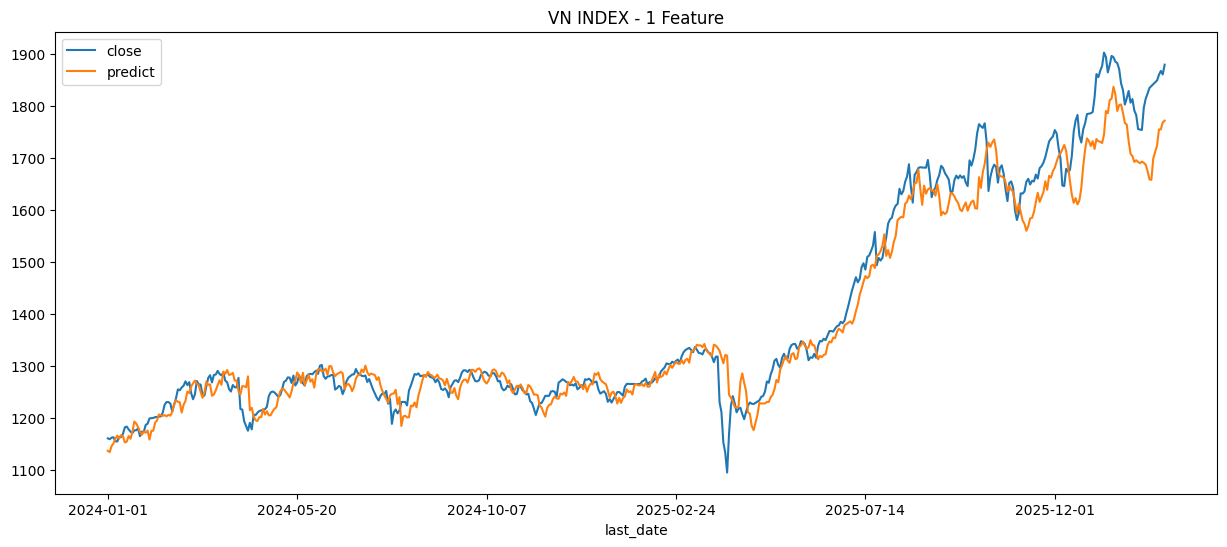

In [120]:
plt.figure(figsize=(15, 6))
plt.title("VN INDEX - 1 Feature")

y_test.plot(ax=plt.gca(), legend="close")
y_predict_plot.plot(ax=plt.gca(), legend="predict", marker=None)

plt.show()

In [121]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

# Convert to numpy arrays (flatten in case they are DataFrames)
y_true = y_test.values.flatten()
y_pred = y_predict_plot.values.flatten()

In [122]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1️⃣ MSE (Mean Squared Error)
mse = mean_squared_error(y_true, y_pred)

# 2️⃣ MAPE (Mean Absolute Percentage Error)
# Avoid division by zero
mape = np.mean(np.where(y_true == 0, 0, np.abs((y_true - y_pred) / y_true))) * 100

# 3️⃣ RMSSE (Root Mean Squared Scaled Error)
# RMSSE needs scaling by naive forecast (lag-1)
denominator = np.mean(np.diff(y_true) ** 2)
rmsse = np.sqrt(mse / denominator)

# 4️⃣ SMAPE (Symmetric MAPE)
denom = np.abs(y_true) + np.abs(y_pred)
smape = np.mean(np.where(denom == 0, 0, 2 * np.abs(y_pred - y_true) / denom)) * 100

# 5️⃣ WAPE (Weighted Absolute Percentage Error)
wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

# 6️⃣ R² (Coefficient of Determination)
r2 = r2_score(y_true, y_pred)

# 7️⃣ Adjusted R²
# Requires number of samples (n) and features (p)
n = len(y_true)
p = X_test_scaled.shape[1]  # make sure X_test exists

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# -----------------------
# Print results
# -----------------------

print(f"MSE: {mse:.4f}")
print(f"MAPE: {mape:.4f} %")
print(f"RMSSE: {rmsse:.4f}")
print(f"SMAPE: {smape:.4f} %")
print(f"WAPE: {wape:.4f}")
print(f"R2: {r2:.4f}")
print(f"Adjusted R2: {adj_r2:.4f}")

MSE: 2215.4468
MAPE: 2.1780 %
RMSSE: 3.0822
SMAPE: 2.1947 %
WAPE: 0.0232
R2: 0.9496
Adjusted R2: 0.9187


### Predict

In [123]:
# Get last row and keep 2D shape
last_row = X_test_scaled[-1:]
last_row.shape

(1, 212)

In [124]:
# Convert to tensor
last_row_tensor = torch.tensor(last_row, dtype=torch.float32)

with torch.no_grad():
    y_pred = model(last_row_tensor)

y_pred_inverse = y_scaler.inverse_transform(y_pred.cpu().numpy().reshape(-1, 1))

y_predict = pd.DataFrame(
    y_pred_inverse, index=[X_test_selected.index[-1]], columns=["predict"]
)

y_predict.squeeze()

1771.8396

### Save data

In [125]:
import os
import sys
import pickle
import ipynbname
import json
from torch.utils.tensorboard import SummaryWriter

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from utils.utils import get_current_run_path, save_prediction_figure

result_folder = get_current_run_path()

NB_NAME = ipynbname.name()

# -----------------------
# Save model
# -----------------------
pickle_path = os.path.join(result_folder, "model.pkl")
with open(pickle_path, "wb") as f:
    pickle.dump(model, f)


# -----------------------
# Save metrics to JSON
# -----------------------
result_path = os.path.join(result_folder, "result.json")

results = {
    "MSE": mse,
    "MAPE": mape,
    "RMSSE": rmsse,
    "SMAPE": smape,
    "WAPE": wape,
    "R2": r2,
    "Adjusted_R2": adj_r2,
}

with open(result_path, "w") as f:
    json.dump(results, f, indent=4)

# -----------------------
# Save prediction figure
# -----------------------
fig_path = os.path.join(result_folder, f"{NB_NAME}.jpg")

save_prediction_figure(
    y_test=y_test, y_predict=y_predict_plot, save_path=fig_path, title=f"{NB_NAME}"
)

writer = SummaryWriter(result_folder)

writer.add_scalar("Metrics/MSE", mse, 0)
writer.add_scalar("Metrics/MAPE", mape, 0)
writer.add_scalar("Metrics/RMSSE", rmsse, 0)

writer.close()

print(f"Saved results to: {result_folder}")

Saved results to: lightning_logs\version_53


In [126]:
from win11toast import toast
import ipynbname

NB_NAME = ipynbname.name()

# Simple notification
toast("Completed training", f"Model '{NB_NAME}' trained successfully.")

<Future pending>